In [11]:
from rich import print

from cali.analysis import AnalysisRunner
from cali.detection import DetectionRunner
from cali.sqlmodel import AnalysisSettings, DetectionSettings

In [ ]:
data_path = "tests/test_data/evoked/evk.tensorstore.zarr"

In [13]:
d = DetectionRunner()
a = AnalysisRunner()

In [ ]:
dst = DetectionSettings(method="cellpose", model_type="cpsam")
fovs = list(d.run(data_path, dst, [0]))

In [15]:
for fov in fovs:
    roi_info = []
    for roi in fov.rois:
        roi_info.append(f"ROI: {roi.label_value}, Mask: {roi.roi_mask is not None}")
    print(roi_info)

<generator object DetectionRunner.run at 0x13c744740>

2025-11-22 13:33:41,895 - cali_logger - INFO - Use GPU: True
2025-11-22 13:33:41,895 - cali_logger - INFO - Loading model from `cpsam`.
2025-11-22 13:33:41,895 - cali_logger - INFO - Loading model from `cpsam`.
2025-11-22 13:33:43,838 - cali_logger - INFO - Loading images for batch processing...
2025-11-22 13:33:43,838 - cali_logger - INFO - Loading images for batch processing...
2025-11-22 13:33:43,851 - cali_logger - INFO - Processing 1 images in batches of 8
Running Cellpose: 100%|██████████| 1/1 [00:02<00:00,  2.16s/it]


['ROI: 1, Mask: True', 'ROI: 2, Mask: True', 'ROI: 3, Mask: True', 'ROI: 4, Mask: True']

2025-11-22 13:33:46,012 - cali_logger - INFO - ✅ Detection complete: 4 ROIs detected across 1 FOVs


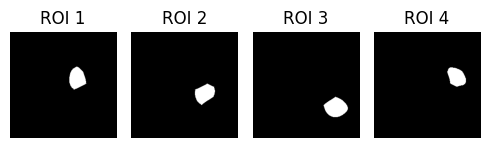

In [7]:
import matplotlib.pyplot as plt

from cali.util import coordinates_to_mask

# Plot all ROIs in a single figure
n_rois = len(fov.rois)
n_cols = 4
n_rows = (n_rois + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5, 2))
if n_rows == 1:
    axes = axes.reshape(1, -1)  # Ensure 2D array even for single row

for i, roi in enumerate(fov.rois):
    row = i // n_cols
    col = i % n_cols

    mask = coordinates_to_mask(
        (roi.roi_mask.coords_x, roi.roi_mask.coords_y),
        (roi.roi_mask.height, roi.roi_mask.width),
    )
    axes[row, col].imshow(mask, cmap="gray")
    axes[row, col].set_title(f"ROI {roi.label_value}")
    axes[row, col].axis("off")

# Hide any unused subplots
for i in range(n_rois, n_rows * n_cols):
    row = i // n_cols
    col = i % n_cols
    axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [8]:
ast = AnalysisSettings(dff_window=150)
fovs = list(a.run(data_path, ast, fovs, [0]))

2025-11-22 13:16:53,407 - cali_logger - INFO - Extracting Traces Data from B5_0000.
Extracting Traces Data from B5_0000.:   0%|          | 0/4 [00:00<?, ?it/s]/Users/fdrgsp/Documents/git/cali/.venv/lib/python3.13/site-packages/oasis/functions.py:849: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 153, using nperseg = 153
  ff, Pxx = scipy.signal.welch(y)
/Users/fdrgsp/Documents/git/cali/.venv/lib/python3.13/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arrange(lags)],
Extracting Traces Data from B5_0000.: 100%|██████████| 4/4 [00:00<00:00, 177.82it/s]
2025-11-22 13:16:53,432 - cali_logger - INFO - ✅ Analysis complete: 4 ROIs analyzed across 1 FOVs
/Users/fdrgsp/Documents/git/cali/.venv/lib/python3.13/site-packages/o

[FOV(name='B5_0000', position_index=0, fov_number=0, id=None, fov_metadata=None, well_id=None, detection_settings_id=None)]

In [9]:
for fov in fovs:
    roi_info = []
    for roi in fov.rois:
        print(
            f"ROI: {roi.label_value}, Traces: {roi.traces_history is not None and len(roi.traces_history) > 0}"
        )

[
    FOV(
        name='B5_0000',
        position_index=0,
        fov_number=0,
        id=None,
        fov_metadata=None,
        well_id=None,
        detection_settings_id=None
    )
]

ROI: 1, Traces: True

ROI: 2, Traces: True

ROI: 3, Traces: True

ROI: 4, Traces: True

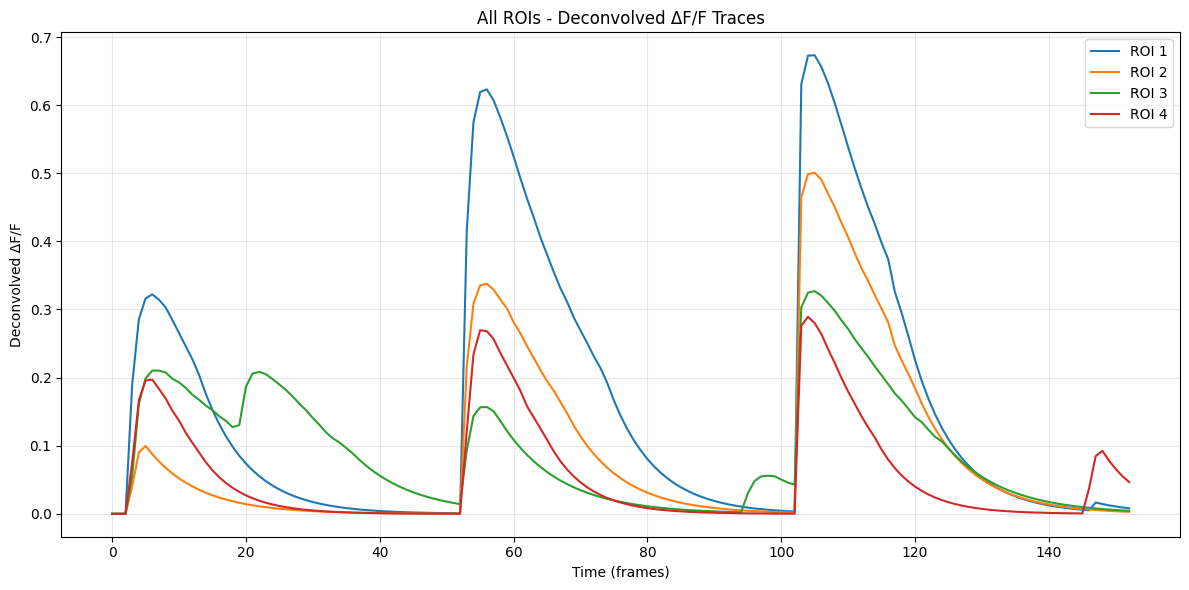

In [10]:
# Plot all dec_dff traces on the same plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for roi in fov.rois:
    if roi.traces_history and len(roi.traces_history) > 0:
        trace = roi.traces_history[0]
        plt.plot(trace.dec_dff, linewidth=1.5, label=f"ROI {roi.label_value}")

plt.title("All ROIs - Deconvolved ΔF/F Traces")
plt.xlabel("Time (frames)")
plt.ylabel("Deconvolved ΔF/F")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()